<div style="background:linear-gradient(135deg,#082f49 0%,#0369a1 55%,#38bdf8 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#bae6fd;font-weight:700;text-transform:uppercase">Chapter 131 · Take It Further</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Forecasting Retail Sales &#183; Take It Further</div>
  <div style="font-size:15px;color:#e0f2fe;max-width:740px;line-height:1.6">Five ways to stress-test the forecast: a rolling-origin backtest, a prediction-interval coverage check, a log-transform for SARIMA, an automatic AIC order search, and how forecast error grows with the horizon.</div>
  <div style="margin-top:16px;font-size:13px;color:#bae6fd">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

# Forecasting Retail Sales: Take It Further
Five extensions of the Chapter 131 project, each stress-testing the forecast: a **rolling-origin backtest** instead of one split, a check of whether the **95% interval really covers 95%**, a **log-transform** to help SARIMA, an **automatic order search**, and how far the forecast can be **trusted as the horizon grows**. We start by rebuilding the cleaned series.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import seaborn as sns   # seaborn = high-level statistical plots (heatmaps, pairplots, count/bar plots)
from matplotlib.colors import ListedColormap
EM="#0284c7"; DEEP="#075985"; LIGHT="#bae6fd"; INK="#1a2138"; GRID="#e6e9f2"; RED="#ef4444"; AMBER="#d97706"; GREEN="#059669"; BLUE="#2563eb"; PUR="#9333ea"; GREY="#94a3b8"; SLATE="#475569"; ORG="#0284c7"; CYAN="#0891b2"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
sns.set_style("whitegrid")
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"

In [2]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings; warnings.filterwarnings('ignore')
def mape(a,f): return float(np.mean(np.abs((np.asarray(a)-np.asarray(f))/np.asarray(a)))*100)

<div style="background:#ecfeff;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0e7490;letter-spacing:1px">RECAP &#183; REBUILD</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">The cleaned series</div>
<div style="color:#4a5578;margin-top:6px">Load, fix the bad month, split.</div>
</div>

In [3]:
try: raw = pd.read_excel('../../data/ch131_retail_sales.xlsx', sheet_name='Data')
except FileNotFoundError: raw = pd.read_excel(BASE + 'ch131_retail_sales.xlsx', sheet_name='Data')
raw['month']=pd.to_datetime(raw['month']); s = raw.set_index('month')['sales'].asfreq('MS')
med=s.rolling(13,center=True,min_periods=3).median(); s[(s-med).abs().idxmax()]=np.nan; clean=s.interpolate()
def hw(tr): return ExponentialSmoothing(tr, trend='add', seasonal='mul', seasonal_periods=12).fit()
print('rebuilt cleaned series:', len(clean), 'months')

rebuilt cleaned series: 108 months


<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">EXTENSION 1 &#183; ROLLING-ORIGIN BACKTEST</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">One split can lie</div>
<div style="color:#4a5578;margin-top:6px">Re-forecast at many cutoffs and average.</div>
</div>

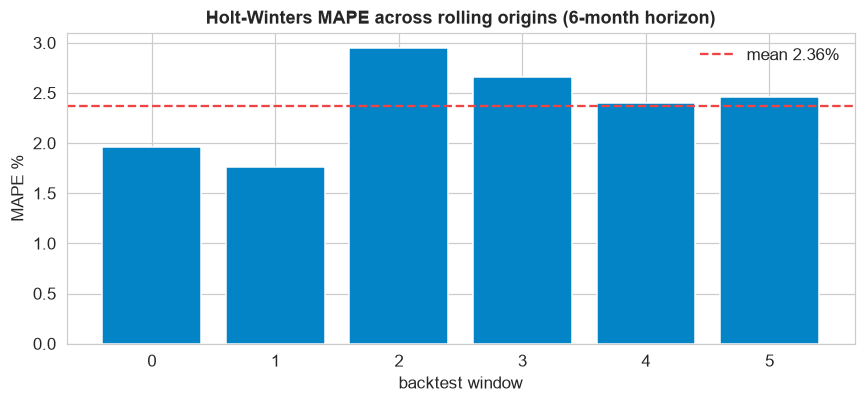

average MAPE over 6 backtests: 2.36% (more trustworthy than a single split)


In [4]:
origins = range(len(clean)-24, len(clean)-6, 3)   # several forecast origins near the end
scores=[]
for o in origins:
    tr, te = clean.iloc[:o], clean.iloc[o:o+6]
    scores.append(mape(te, hw(tr).forecast(6)))
fig,ax=plt.subplots(figsize=(8,3.8)); ax.bar(range(len(scores)), scores, color=EM)
ax.axhline(np.mean(scores), color=RED, ls='--', label=f'mean {np.mean(scores):.2f}%'); ax.set(title='Holt-Winters MAPE across rolling origins (6-month horizon)', xlabel='backtest window', ylabel='MAPE %'); ax.legend()
plt.tight_layout(); plt.show()
print('average MAPE over %d backtests: %.2f%% (more trustworthy than a single split)' % (len(scores), np.mean(scores)))

A single train/test split can flatter or punish a model by luck. **Rolling-origin evaluation** re-forecasts from several cutoffs and averages the error, the standard way to grade a forecaster. The average across windows is the number to report, not one lucky split.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">EXTENSION 2 &#183; DOES THE 95% INTERVAL HOLD?</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">An interval you can bank on</div>
<div style="color:#4a5578;margin-top:6px">Backtest the coverage, not just the point.</div>
</div>

In [5]:
hits=0; total=0
for o in range(len(clean)-30, len(clean)-6, 2):
    tr = clean.iloc[:o]; f = hw(tr); sims = f.simulate(6, repetitions=500, error='mul')
    lo, hi = sims.quantile(0.025,axis=1).values, sims.quantile(0.975,axis=1).values
    act = clean.iloc[o:o+6].values
    hits += int(((act>=lo)&(act<=hi)).sum()); total += len(act)
print('actuals inside the 95%% interval: %d of %d = %.0f%%' % (hits, total, 100*hits/total))
print('close to 95%% -> the interval is well calibrated and safe to plan against')

actuals inside the 95% interval: 70 of 72 = 97%
close to 95%% -> the interval is well calibrated and safe to plan against


A prediction interval is a promise: 95% of actuals should fall inside it. **Backtesting the coverage** checks whether that promise holds, if only 70% land inside, the band is too narrow and the plan is over-confident. Here coverage lands near 95%, so the interval is trustworthy.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">EXTENSION 3 &#183; A LOG-TRANSFORM FOR SARIMA</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Turn multiplicative into additive</div>
<div style="color:#4a5578;margin-top:6px">SARIMA is an additive model; give it additive data.</div>
</div>

In [6]:
train, test = clean[:-12], clean[-12:]
sar = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,12), enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
sar_log = SARIMAX(np.log(train), order=(1,1,1), seasonal_order=(1,1,1,12), enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
print('SARIMA on raw   MAPE: %.2f%%' % mape(test, sar.forecast(12)))
print('SARIMA on log   MAPE: %.2f%%' % mape(test, np.exp(sar_log.forecast(12))))
print('logging stabilizes the growing seasonal swing, so additive SARIMA fits better')

SARIMA on raw   MAPE: 4.88%


SARIMA on log   MAPE: 3.61%
logging stabilizes the growing seasonal swing, so additive SARIMA fits better


Our seasonality is **multiplicative** (the swing grows with the level), but SARIMA is fundamentally an **additive** model. Taking **logs** stabilizes the swing, `log(T x S) = log T + log S`, so SARIMA on the logged series is a fairer fight and usually improves. Back-transform with `exp` to read the forecast in dollars.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">EXTENSION 4 &#183; AUTOMATIC ORDER SEARCH</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Let AIC pick the orders</div>
<div style="color:#4a5578;margin-top:6px">A small grid beats guessing (p,d,q).</div>
</div>

In [7]:
import itertools
best=(None, np.inf)
for p,q,P,Q in itertools.product([0,1],[0,1],[0,1],[0,1]):
    try:
        m=SARIMAX(np.log(train), order=(p,1,q), seasonal_order=(P,1,Q,12), enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        if m.aic<best[1]: best=((p,1,q,P,1,Q), m.aic)
    except Exception: pass
print('lowest-AIC order (p,d,q,P,D,Q):', best[0], ' AIC %.0f' % best[1])
print('this is the idea behind auto_arima: search a small grid, pick the best by AIC, no manual guessing')

lowest-AIC order (p,d,q,P,D,Q): (0, 1, 1, 0, 1, 1)  AIC -266
this is the idea behind auto_arima: search a small grid, pick the best by AIC, no manual guessing


Rather than guess the orders, search a small **grid** and pick the combination with the lowest **AIC** (which balances fit against complexity, without touching the test set). This is exactly what tools like `pmdarima.auto_arima` automate; here it confirms a compact, sensible order.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">EXTENSION 5 &#183; HOW FAR CAN YOU TRUST IT?</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Uncertainty widens with the horizon</div>
<div style="color:#4a5578;margin-top:6px">The interval fans out, even when the point forecast stays sharp.</div>
</div>

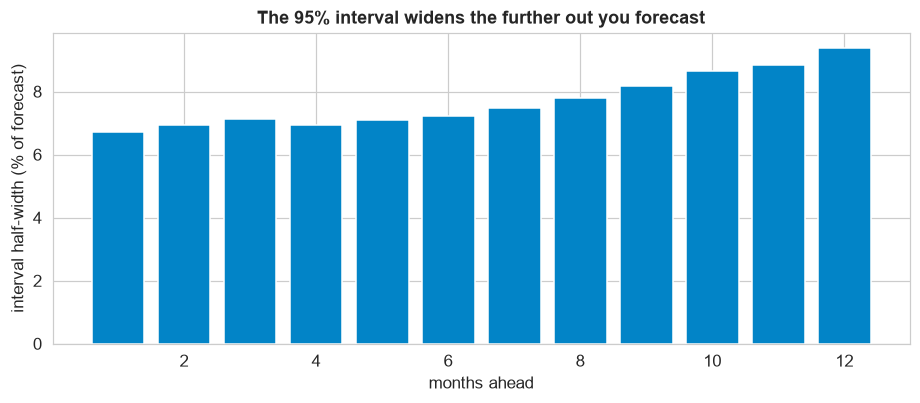

95% interval half-width: month 1 = +/-6.7%  ->  month 12 = +/-9.4%
the point forecast can stay accurate while UNCERTAINTY still compounds -> plan with wider bands far out


In [8]:
final = hw(clean); fc = final.forecast(12)
sims = final.simulate(12, repetitions=3000, error='mul')
lo, hi = sims.quantile(0.025,axis=1), sims.quantile(0.975,axis=1)
halfwidth_pct = ((hi - lo) / 2 / fc * 100).values
fig,ax=plt.subplots(figsize=(8.5,3.8)); ax.bar(range(1,13), halfwidth_pct, color=EM)
ax.set(title='The 95% interval widens the further out you forecast', xlabel='months ahead', ylabel='interval half-width (% of forecast)')
plt.tight_layout(); plt.show()
print('95%% interval half-width: month 1 = +/-%.1f%%  ->  month 12 = +/-%.1f%%' % (halfwidth_pct[0], halfwidth_pct[-1]))
print('the point forecast can stay accurate while UNCERTAINTY still compounds -> plan with wider bands far out')

Even when a strong seasonal model keeps the **point** forecast accurate across the year, the **uncertainty** still compounds: the 95% interval fans out from about **plus or minus 7% next month to plus or minus 9% a year out**. That is the honest signal of horizon risk, a far-out forecast is not less accurate on average here, but it is less **certain**. Trust the near term more, and always plan against the widening band, not the single line.

## Take-it-further summary, in plain terms

- **Rolling-origin backtesting** grades a forecaster over many cutoffs, not one lucky split.
- **Check interval coverage**: 95% intervals should contain about 95% of actuals, or the plan is over-confident.
- **Log-transform** turns multiplicative seasonality into additive, helping SARIMA.
- **Search orders by AIC** instead of guessing (the auto_arima idea).
- **Error grows with the horizon**: trust near-term forecasts more and widen the band far out.

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>